# 02 · CRISP-DM aplicado y preparación de datos sin fugas

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 2 · Semana 3 · RA2 (CE 2.1–2.2) · 120–150 minutos.**
Recorrerás las primeras fases de CRISP-DM con FinCordillera: formularás criterios de éxito, auditarás los datos, tratarás vacíos y valores extremos, particionarás y prepararás variables dentro de un pipeline.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

In [1]:
from pathlib import Path
import sys
import warnings
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .18, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format",
              lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


<a id="crisp"></a>

## CRISP-DM con entregables verificables

CRISP-DM organiza un proyecto en seis fases iterativas. Cada fase debe dejar un **entregable revisable** y un
**criterio de salida**; si no lo hay, la fase solo existe en la diapositiva.

| Fase | Pregunta central | Entregable | Criterio de salida |
|---|---|---|---|
| 1 · Comprensión del negocio | ¿Qué decisión mejora y cómo se medirá? | Ficha del problema: Y, unidad, horizonte, decisión, costos | El gerente valida la formulación |
| 2 · Comprensión de los datos | ¿Los datos representan a quienes se decidirá? | Contrato de datos y exploración dirigida | Variables disponibles al decidir; calidad documentada |
| 3 · Preparación | ¿Qué transformaciones son necesarias y reproducibles? | Pipeline de preparación | Ajustado solo con entrenamiento |
| 4 · Modelamiento | ¿Qué familias de modelos compiten? | Modelos y línea base | Comparación en validación con la métrica guía |
| 5 · Evaluación | ¿Cumple el criterio técnico y el de negocio? | Informe de evaluación y límites | Prueba consultada una vez; costos explícitos |
| 6 · Despliegue | ¿Cómo se usa, se monitorea y se retira? | Ficha del modelo y plan de monitoreo | Responsables, umbrales de alerta y fecha de revisión |

**Formulación FinCordillera.** Estimar qué clientes tienen mayor probabilidad de abandonar en el próximo trimestre
para focalizar una oferta de retención con presupuesto limitado. **Criterio técnico:** precisión promedio (AP) en
validación al menos el doble de la tasa base y AUC ≥ 0,70. **Criterio de negocio:** beneficio neto positivo bajo
supuestos de costo declarados (notebook 04).

<a id="contrato"></a>

## Comprender los datos: contrato y exploración dirigida (CE 2.1)

Un **contrato de datos** declara tipo, dominio y unicidad esperados. Si una regla falla, el problema se resuelve
antes de modelar. La exploración se dirige a la pregunta: tasa del evento, relación de cada variable con el evento
y tamaño de los grupos.

In [2]:
banco = mr.fincordillera_clientes()          # la función ya verifica unicidad, dominios y vacíos
contrato = pd.DataFrame({"tipo": banco.dtypes.astype(str), "vacíos": banco.isna().sum(),
                         "valores_distintos": banco.nunique(),
                         "mínimo": banco.min(numeric_only=True), "máximo": banco.max(numeric_only=True)})
display(contrato)
print(f"Filas duplicadas: {banco.duplicated().sum()} · clientes únicos: {banco.cliente_id.is_unique}")
por_region = banco.groupby("region").agg(clientes=("churn", "size"), tasa_abandono=("churn", "mean"))
display(por_region.sort_values("tasa_abandono", ascending=False).round(3))

,tipo,vacíos,valores_distintos,mínimo,máximo
antiguedad_meses,int64,0,167,2,179
churn,int64,0,2,0,1
cliente_id,int64,0,950,"1,001","1,950"
edad,int64,0,56,19,74
frecuencia_reclamos_12m,int64,0,8,0,7
ingreso_mensual_clp,int64,0,661,"350,000","2,400,000"
num_productos_contratados,int64,0,5,1,5
region,str,0,5,NaN,NaN
retrasos_pago_12m,int64,0,6,0,5
uso_app_movil_mensual,int64,0,18,1,19


Filas duplicadas: 0 · clientes únicos: True


,clientes,tasa_abandono
region,,
La Araucania,138,0.341
Metropolitana,366,0.301
Biobio,166,0.259
Antofagasta,125,0.240
Valparaiso,155,0.232


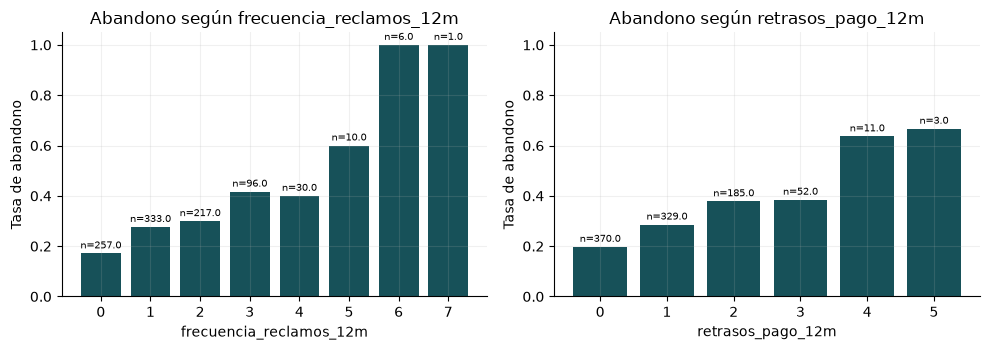

In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.6))
for eje, variable in zip(ejes, ["frecuencia_reclamos_12m", "retrasos_pago_12m"]):
    resumen = banco.groupby(variable)["churn"].agg(["mean", "size"])
    eje.bar(resumen.index, resumen["mean"], color="#175159")
    for x_, (tasa, n) in resumen.iterrows():
        eje.text(x_, tasa + .02, f"n={n}", ha="center", fontsize=7)
    eje.set(xlabel=variable, ylabel="Tasa de abandono", ylim=(0, 1.05), title=f"Abandono según {variable}")
plt.tight_layout(); plt.show()

**Lectura.** La tasa de abandono crece con reclamos y retrasos: hay señal para modelar. Las barras de la derecha
descansan en pocos clientes (ver `n`); una tasa de 100% con tres casos no es evidencia sólida. Las diferencias entre
regiones son pequeñas frente a su tamaño muestral: no se deben convertir en una política regional sin más análisis.

<a id="calidad"></a>

## Calidad de datos: vacíos y valores extremos (CE 2.2)

El archivo original no tiene vacíos. Para practicar se crea una **copia con defectos simulados y documentados**:

- 8% de vacíos completamente al azar en antigüedad (MCAR);
- vacíos de ingreso mucho más frecuentes cuando el ingreso es alto (MNAR: dependen del propio valor no observado);
- cinco ingresos multiplicados por 10, como un error de digitación.

In [4]:
g = np.random.default_rng(SEMILLA)
sucio = banco.copy()
sucio.loc[g.random(len(sucio)) < .08, "antiguedad_meses"] = np.nan
alto = banco["ingreso_mensual_clp"] > banco["ingreso_mensual_clp"].quantile(.75)
sucio.loc[g.random(len(sucio)) < np.where(alto, .45, .05), "ingreso_mensual_clp"] = np.nan
errores = sucio["ingreso_mensual_clp"].dropna().sample(5, random_state=SEMILLA).index
sucio.loc[errores, "ingreso_mensual_clp"] *= 10

comparacion = pd.DataFrame({
    "original": [banco.antiguedad_meses.mean(), banco.ingreso_mensual_clp.mean(), banco.ingreso_mensual_clp.median()],
    "casos completos de la copia": [sucio.antiguedad_meses.mean(), sucio.ingreso_mensual_clp.mean(),
                                    sucio.ingreso_mensual_clp.median()]},
    index=["media de antigüedad (MCAR)", "media de ingreso (MNAR + errores)", "mediana de ingreso (MNAR + errores)"])
display(comparacion)
print("Vacíos por columna:", sucio.isna().sum()[sucio.isna().sum() > 0].to_dict())

q1, q3 = sucio["ingreso_mensual_clp"].quantile([.25, .75])
limite_iqr = q3 + 1.5 * (q3 - q1)
marcados_iqr = sucio.index[sucio["ingreso_mensual_clp"] > limite_iqr]
print(f"Regla IQR: límite superior {limite_iqr:,.0f} · casos marcados: {len(marcados_iqr)} · "
      f"errores simulados detectados: {len(set(marcados_iqr) & set(errores))} de {len(errores)}")

,original,casos completos de la copia
media de antigüedad (MCAR),82.904,82.944
media de ingreso (MNAR + errores),"1,117,160","1,103,667"
mediana de ingreso (MNAR + errores),"1,037,500","984,000"


Vacíos por columna: {'antiguedad_meses': 64, 'ingreso_mensual_clp': 145}
Regla IQR: límite superior 1,919,000 · casos marcados: 30 · errores simulados detectados: 5 de 5


**Decisiones de calidad.**

| Situación | Evidencia | Tratamiento razonable |
|---|---|---|
| Error de digitación (ingreso ×10) | Valor imposible para el segmento, confirmado con la fuente | Corregir en origen o marcar como vacío; no «recortar» sin registro |
| Valor extremo legítimo | Cliente real de alto ingreso | Conservar; evaluar transformación (logaritmo) o modelos robustos |
| Vacíos MCAR | No dependen de nada: la media de antigüedad casi no cambia | Imputación simple con estadísticos de entrenamiento |
| Vacíos MAR | Dependen de otra variable observada (por ejemplo, canal) | Imputar condicionando en esa variable y agregar indicador de vacío |
| Vacíos MNAR | Dependen del valor faltante: los ingresos altos se informan menos | Ningún método lo corrige solo con los datos; agregar indicador, buscar fuente alternativa y declarar el sesgo |

En la copia, la **mediana** de ingreso de casos completos cae porque faltan sobre todo ingresos altos (MNAR), mientras
la **media** mezcla ese sesgo con el de los cinco errores ×10, que la empujan hacia arriba: los efectos se
compensan en parte, y por eso un promedio de apariencia razonable no garantiza datos sanos. La antigüedad, con vacíos al azar,
casi no cambia. Un mismo porcentaje de vacíos puede ser inocuo o sesgar la conclusión: lo decide el mecanismo.

<a id="fuga-preparacion"></a>

## Fuga en la preparación: seleccionar variables antes de validar

Toda decisión aprendida de los datos —imputar, escalar, elegir variables— debe repetirse **dentro** de cada
partición de validación. El ejemplo clásico usa 2.000 variables de **ruido puro** y una respuesta al azar: no existe
señal y el AUC correcto es cercano a 0,5.

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

g = np.random.default_rng(SEMILLA)
X_ruido = g.normal(size=(200, 2000))
y_ruido = g.integers(0, 2, 200)
cv = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)

seleccion_previa = SelectKBest(f_classif, k=20).fit(X_ruido, y_ruido)      # mira todas las filas: fuga
auc_con_fuga = cross_val_score(LogisticRegression(max_iter=1000), seleccion_previa.transform(X_ruido), y_ruido,
                               cv=cv, scoring="roc_auc").mean()
pipeline_correcto = Pipeline([("seleccionar", SelectKBest(f_classif, k=20)),
                              ("modelo", LogisticRegression(max_iter=1000))])
auc_correcto = cross_val_score(pipeline_correcto, X_ruido, y_ruido, cv=cv, scoring="roc_auc").mean()
display(pd.Series({"Selección antes de validar (fuga)": auc_con_fuga,
                   "Selección dentro del pipeline": auc_correcto}).round(3).to_frame("AUC validación cruzada"))

,AUC validación cruzada
Selección antes de validar (fuga),0.821
Selección dentro del pipeline,0.444


**Lectura.** Con la selección previa, la validación cruzada «encuentra» señal donde solo hay ruido: las 20 variables
se eligieron mirando las etiquetas de todas las filas, incluidas las de validación. Dentro del pipeline, cada pliegue
elige sus variables solo con su entrenamiento y el AUC vuelve cerca de 0,5.

<a id="particion"></a>

## Partición entrenamiento / validación / prueba

- **Entrenamiento (60%)**: aprende parámetros y transformaciones.
- **Validación (20%)**: compara modelos, elige hiperparámetros, umbral y costos.
- **Prueba (20%)**: se consulta **una vez**, al final, con todo congelado.

La estratificación conserva la proporción de abandono en las tres partes. Si los datos tienen orden temporal se
particiona por tiempo; si un cliente aparece varias veces, por grupos. Una partición aleatoria sería optimista.

In [6]:
X = banco.drop(columns=["cliente_id", "churn"])
y = banco["churn"]
Xe, Xv, Xt, ye, yv, yt = mr.particion_tres(X, y)
particion = pd.DataFrame({"filas": [len(ye), len(yv), len(yt)], "tasa_abandono": [ye.mean(), yv.mean(), yt.mean()]},
                         index=["entrenamiento", "validación", "prueba"])
display(particion.round(3))
assert set(Xe.index).isdisjoint(Xt.index) and set(Xv.index).isdisjoint(Xt.index)

,filas,tasa_abandono
entrenamiento,570,0.281
validación,190,0.279
prueba,190,0.279


<a id="pipeline"></a>

## Pipeline: preparar y modelar sin contaminar

Un `Pipeline` encadena imputación, escalamiento, codificación y modelo. Al llamar `.fit` con entrenamiento, cada
paso aprende **solo** de esas filas; al predecir validación se aplican las mismas transformaciones. El control
inyecta vacíos en copias de entrenamiento y validación y compara estrategias de imputación.

In [7]:
numericas = X.select_dtypes("number").columns.tolist()
categoricas = ["region"]
modelo = Pipeline([("preparar", mr.preprocesador(numericas, categoricas)),
                   ("modelo", LogisticRegression(max_iter=2000))]).fit(Xe, ye)
nombres = modelo.named_steps["preparar"].get_feature_names_out()
auc_base = roc_auc_score(yv, modelo.predict_proba(Xv)[:, 1])
print(f"{len(nombres)} columnas tras preparar · AUC validación sin vacíos: {auc_base:.3f}")

def explorar_imputacion(estrategia="median", porcentaje=10):
    g = np.random.default_rng(SEMILLA + porcentaje)
    Xe2, Xv2 = Xe.copy(), Xv.copy()
    for marco in (Xe2, Xv2):
        for columna in ["ingreso_mensual_clp", "uso_app_movil_mensual", "antiguedad_meses"]:
            marco.loc[g.random(len(marco)) < porcentaje / 100, columna] = np.nan
    preparar = mr.preprocesador(numericas, categoricas)
    preparar.set_params(num__imputar__strategy=estrategia)
    m = Pipeline([("preparar", preparar), ("modelo", LogisticRegression(max_iter=2000))]).fit(Xe2, ye)
    auc = roc_auc_score(yv, m.predict_proba(Xv2)[:, 1])
    imputador = m.named_steps["preparar"].named_transformers_["num"].named_steps["imputar"]
    valor = imputador.statistics_[numericas.index("ingreso_mensual_clp")]
    resultado = pd.Series({"AUC validación": auc, "ingreso imputado (aprendido en entrenamiento)": valor,
                           "celdas vacías en entrenamiento": int(Xe2.isna().sum().sum())})
    display(resultado.to_frame("valor"))
    return resultado

imputacion_base = explorar_imputacion()
widgets.interact(explorar_imputacion,
                 estrategia=widgets.Dropdown(options=["median", "mean", "most_frequent"], value="median"),
                 porcentaje=widgets.IntSlider(value=10, min=0, max=60, step=5, description="% vacíos"));

11 columnas tras preparar · AUC validación sin vacíos: 0.715


,valor
AUC validación,0.714
ingreso imputado (aprendido en entrenamiento),"1,057,000"
celdas vacías en entrenamiento,172


interactive(children=(Dropdown(description='estrategia', options=('median', 'mean', 'most_frequent'), value='m…

**Lectura.** El valor imputado proviene solo del entrenamiento: se aplicará igual a clientes futuros. Con muchos
vacíos el AUC cae porque se pierde información, no porque la imputación «falle». La mediana resiste mejor los
valores extremos que la media. La moda tiene sentido para variables discretas, no para ingresos.

### Ejercicios resueltos

1. **Orden correcto.** ¿Se estandariza antes o después de particionar? Después, y dentro del pipeline: la media y la
   desviación estándar se aprenden con entrenamiento.
2. **Vacíos MNAR.** Si los ingresos altos se informan menos, ¿basta imputar la mediana? No: la mediana de
   entrenamiento también está sesgada. Conviene agregar un indicador de vacío, buscar otra fuente (por ejemplo,
   abonos de remuneración) y declarar la limitación en la ficha del modelo.
3. **Criterio de éxito.** Con tasa base 28%, el criterio «AP ≥ 2×tasa base» exige AP ≥ 0,56 en validación.

In [8]:
auto_02 = pregunta("Se seleccionan 20 variables con todas las filas y luego se hace validación cruzada. ¿Qué ocurre?",
                   ["La validación sigue siendo independiente", "La selección usó etiquetas de validación: el resultado es optimista",
                    "Solo cambia el tiempo de cómputo"], 1,
                   "Toda decisión aprendida de los datos debe repetirse dentro de cada partición de entrenamiento.")
assert auc_con_fuga - auc_correcto > .15
assert abs(ye.mean() - yt.mean()) < .02
assert imputacion_base["AUC validación"] > .6
assert comparacion.loc["mediana de ingreso (MNAR + errores)", "casos completos de la copia"] < comparacion.loc["mediana de ingreso (MNAR + errores)", "original"]
print("Comprobaciones del laboratorio 02: OK")

Comprobaciones del laboratorio 02: OK


### Referencias

[IBM: metodología CRISP-DM](https://www.ibm.com/docs/es/spss-modeler/saas?topic=dm-crisp-help-overview) ·
[scikit-learn: pipelines y transformaciones compuestas](https://scikit-learn.org/stable/modules/compose.html) ·
[scikit-learn: errores frecuentes](https://scikit-learn.org/stable/common_pitfalls.html) ·
Hastie, Tibshirani y Friedman, *The Elements of Statistical Learning*, sección 7.10.2 (la forma incorrecta de hacer
validación cruzada).